In [1]:
import numpy as np
import pandas as pd

In [2]:
fold0 = pd.read_csv(f"/scratch1/smaruj/CTCF_elimination/gamma_300.0/fold0_g300.0_genomic_windows_table_results.tsv", sep="\t")

fold0["fold"] = [0 for i in range(len(fold0))]

In [3]:
fold1 = pd.read_csv(f"/scratch1/smaruj/CTCF_elimination/gamma_300.0/fold1_g300.0_genomic_windows_table_results.tsv", sep="\t")

fold1["fold"] = [1 for i in range(len(fold1))]

In [4]:
fold2 = pd.read_csv(f"/scratch1/smaruj/CTCF_elimination/gamma_300.0/fold2_g300.0_genomic_windows_table_results.tsv", sep="\t")

fold2["fold"] = [2 for i in range(len(fold2))]

In [5]:
fold3 = pd.read_csv(f"/scratch1/smaruj/CTCF_elimination/gamma_300.0/fold3_g300.0_genomic_windows_table_results.tsv", sep="\t")

fold3["fold"] = [3 for i in range(len(fold3))]

In [6]:
fold4 = pd.read_csv(f"/scratch1/smaruj/CTCF_elimination/gamma_300.0/fold4_g300.0_genomic_windows_table_results.tsv", sep="\t")

fold4["fold"] = [4 for i in range(len(fold4))]

In [7]:
fold5 = pd.read_csv(f"/scratch1/smaruj/CTCF_elimination/gamma_300.0/fold5_g300.0_genomic_windows_table_results.tsv", sep="\t")

fold5["fold"] = [5 for i in range(len(fold5))]

In [8]:
fold6 = pd.read_csv(f"/scratch1/smaruj/CTCF_elimination/gamma_300.0/fold6_g300.0_genomic_windows_table_results.tsv", sep="\t")

fold6["fold"] = [6 for i in range(len(fold6))]

In [9]:
fold7 = pd.read_csv(f"/scratch1/smaruj/CTCF_elimination/gamma_300.0/fold7_g300.0_genomic_windows_table_results.tsv", sep="\t")

fold7["fold"] = [7 for i in range(len(fold7))]

In [10]:
df = pd.concat([fold0, fold1, fold2,
                fold3, fold4, fold5,
                fold6, fold7], ignore_index=True)

In [ ]:
len(df)

In [11]:
df["URQ_diff"] = df["URQ_result"] - df["URQ_init"]

In [ ]:
df

In [12]:
# selecting only sequences with no CTCF detected
df = df[df["CTCFs_num"] == 0]

In [ ]:
len(df)

In [13]:
# selecting only sequences with a measurable contact depletion
df = df[df['URQ_diff'] < 0.0]

In [23]:
len(df)

216

In [14]:
df.to_csv(f"/scratch1/smaruj/CTCF_elimination/gamma_300.0/successful_optimizations.tsv", sep="\t", index=False)

### saving sequences to fasta

In [15]:
import torch
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from pyfaidx import Fasta

In [16]:
fasta_file = "/project2/fudenber_735/genomes/mm10/mm10.fa"
sequence_dir = "/scratch1/smaruj/CTCF_elimination/gamma_300.0"
output_fasta = "optimized_sequences_100kb.fasta"

In [17]:
genome = Fasta(fasta_file)

In [18]:
def ohe_to_seq(tensor):
    base_order = ['A', 'C', 'G', 'T']
    tensor = tensor.permute(1, 0)  # now [2048, 4], positions x nucleotides
    indices = torch.argmax(tensor, dim=1)
    return ''.join([base_order[i.item()] for i in indices])

In [19]:
bin_size = 2048
cropping_applied = 64
padding_bins = 0
padding = padding_bins * bin_size

slice_0_bins = [256]
slice_0_start = (min(slice_0_bins) + cropping_applied - padding_bins) * bin_size
slice_0_end = (max(slice_0_bins) + 1 + cropping_applied + padding_bins) * bin_size

In [20]:
from Bio.SeqIO.FastaIO import FastaWriter

In [21]:
# flank = 60
flank = (100000 - 2048) // 2

In [22]:
records = []
for i, row in df.iterrows():
    chrom = row['chrom']
    centered_start = int(row['centered_start'])
    centered_end = int(row['centered_end'])
    start = centered_start + slice_0_start
    end = centered_start + slice_0_end
    fold = row['fold']

    # (1) Get 60 bp upstream
    upstream = genome[chrom][start - flank:start].seq.upper()

    # (2) Read .pt file and decode
    seq_path = f"{sequence_dir}/fold{fold}/{chrom}_{centered_start}_{centered_end}_slice.pt"
    ohe_tensor = torch.load(seq_path)  # shape: (2048, 4)
    seq_string = ohe_to_seq(ohe_tensor.squeeze(0))

    # (3) Get 60 bp downstream
    downstream = genome[chrom][end:end + flank].seq.upper()

    # (4) Combine all parts
    full_seq = upstream + seq_string + downstream

    # (5) Create FASTA record
    header = f"{chrom}_{centered_start}_{centered_end}_optimized"
    record = SeqRecord(Seq(full_seq), id=header, description="")
    records.append(record)

# with open(f"{sequence_dir}/{output_fasta}", "w") as out_f:
#     SeqIO.write(records, out_f, "fasta")

# print(f"✅ Done. {len(records)} sequences written to {output_fasta}")

# Write FASTA with sequences in ONE line
with open(f"{sequence_dir}/{output_fasta}", "w") as out_f:
    writer = FastaWriter(out_f, wrap=None)  # disable line wrapping
    writer.write_file(records)

print(f"✅ Done. {len(records)} sequences written to {output_fasta}")

/tmp/SLURM_1813486/ipykernel_2843558/3617403601.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ohe_tensor = torch.load(seq_path)  # shape: (2048, 4)


✅ Done. 216 sequences written to optimized_sequences_100kb.fasta


### saving the original sequences

In [24]:
fasta_file = "/project2/fudenber_735/genomes/mm10/mm10.fa"
sequence_dir = "/scratch1/smaruj/CTCF_elimination/gamma_300.0"
output_fasta = "original_sequences_100kb.fasta"

In [25]:
records = []
for i, row in df.iterrows():
    chrom = row['chrom']
    centered_start = int(row['centered_start'])
    centered_end = int(row['centered_end'])
    start = centered_start + slice_0_start
    end = centered_start + slice_0_end
    fold = row['fold']

    og_sequence = genome[chrom][start - flank:end + flank].seq.upper()
    
    # Create FASTA record
    header = f"{chrom}_{centered_start}_{centered_end}_original"
    record = SeqRecord(Seq(og_sequence), id=header, description="")
    records.append(record)

# with open(f"{sequence_dir}/{output_fasta}", "w") as out_f:
#     SeqIO.write(records, out_f, "fasta")

with open(f"{sequence_dir}/{output_fasta}", "w") as out_f:
    writer = FastaWriter(out_f, wrap=None)  # disable line wrapping
    writer.write_file(records)

print(f"✅ Done. {len(records)} sequences written to {output_fasta}")

✅ Done. 216 sequences written to original_sequences_100kb.fasta


### Plots

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df.columns

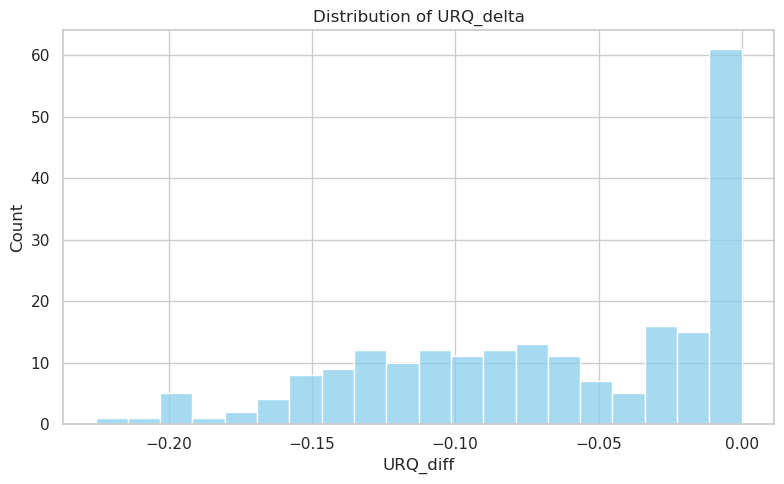

In [27]:
# Set style
sns.set(style="whitegrid")

# Plot histogram with KDE
plt.figure(figsize=(8, 5))
sns.histplot(df['URQ_diff'], kde=False, bins=20, color='skyblue')
plt.title('Distribution of URQ_delta')
plt.xlabel('URQ_diff')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

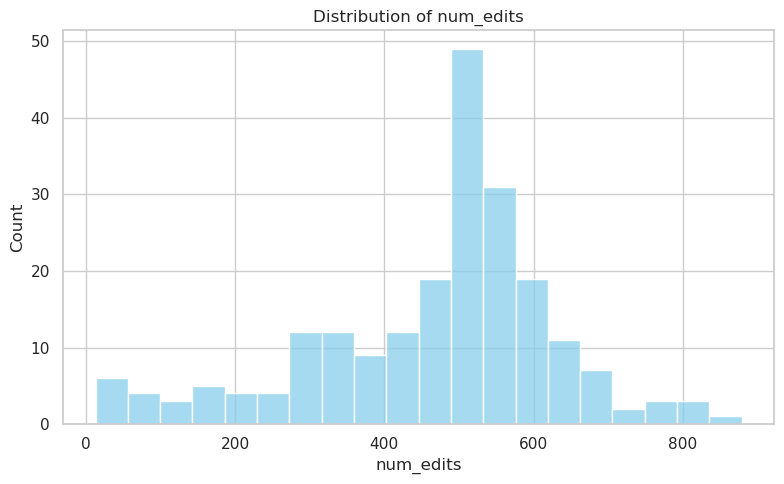

In [28]:
# Set style
sns.set(style="whitegrid")

# Plot histogram with KDE
plt.figure(figsize=(8, 5))
sns.histplot(df['num_edits'], kde=False, bins=20, color='skyblue')
plt.title('Distribution of num_edits')
plt.xlabel('num_edits')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [29]:
from scipy.stats import ttest_rel

In [30]:
t_stat, p_value = ttest_rel(df['URQ_result'], df['URQ_init'])
print(f"Paired t-test: t = {t_stat:.3f}, p = {p_value:.3e}")

Paired t-test: t = -16.628, p = 1.808e-40


/tmp/SLURM_1813486/ipykernel_2843558/3035581949.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Condition', y='Value', data=df_melted, palette='pastel')


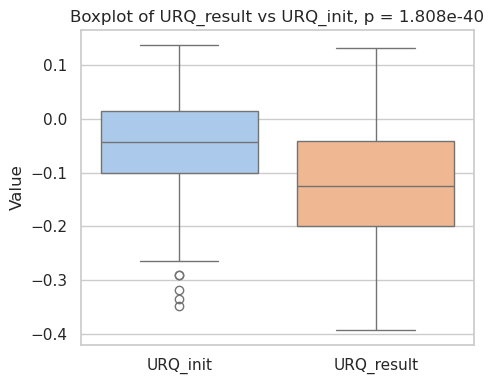

In [31]:
# Reshape for seaborn boxplot
df_melted = df[['URQ_init', 'URQ_result']].melt(var_name='Condition', value_name='Value')

plt.figure(figsize=(5, 4))
sns.boxplot(x='Condition', y='Value', data=df_melted, palette='pastel')
plt.title(f'Boxplot of URQ_result vs URQ_init, p = {p_value:.3e}')
plt.xlabel('')
plt.ylabel('Value')
plt.tight_layout()
plt.show()

In [32]:
t_stat, p_value = ttest_rel(df['GC_slice'], df['GC_slice_edited'])
print(f"Paired t-test: t = {t_stat:.3f}, p = {p_value:.3e}")

Paired t-test: t = -11.894, p = 2.128e-25


/tmp/SLURM_1813486/ipykernel_2843558/266584610.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Condition', y='Value', data=df_melted, palette='pastel')


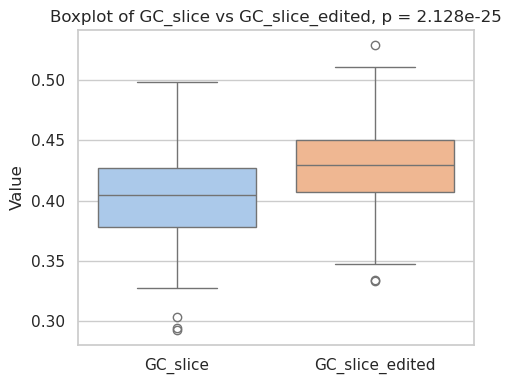

In [33]:
# Reshape for seaborn boxplot
df_melted = df[['GC_slice', 'GC_slice_edited']].melt(var_name='Condition', value_name='Value')

plt.figure(figsize=(5, 4))
sns.boxplot(x='Condition', y='Value', data=df_melted, palette='pastel')
plt.title(f'Boxplot of GC_slice vs GC_slice_edited, p = {p_value:.3e}')
plt.xlabel('')
plt.ylabel('Value')
plt.tight_layout()
plt.show()